# Decision Tree Classification — Earthquake Severity Prediction for Nepal Disaster Preparedness

**Algorithm:** Decision Tree Classifier (Supervised Learning)

**Objective:** Predict the severity class of a historical earthquake (Minor / Light / Moderate / Strong) from its location, depth and instrumentation-quality features, and produce a set of clear, human-readable decision rules that the NDRRA could realistically use as a field reference during disaster response.

### Step 1: Importing all the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

pd.set_option('display.max_columns', None)

### Step 2: Data Collection

Loading the same earthquake catalogue used across the group's report, so that our results stay directly comparable with the other four models.

In [2]:

df = pd.read_csv("Earthquake.csv")

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nEvent type counts:")
print(df["type"].value_counts())

Dataset shape: (17100, 22)

First 5 rows:
                       time  latitude  longitude    depth  mag magType    nst  \
0  2026-05-30T21:15:59.807Z   38.3564    73.8219  131.794  4.9      mb   80.0   
1  2026-05-29T12:22:54.128Z   23.4621    93.7220   57.374  4.3      mb   32.0   
2  2026-05-28T02:37:50.460Z   33.1393    96.1517   10.000  4.7      mb  111.0   
3  2026-05-26T16:30:57.714Z   23.1849    94.5425  102.712  4.3      mb   21.0   
4  2026-05-26T14:07:51.354Z   23.7982    94.8304  112.776  4.5      mb   36.0   

     gap   dmin   rms net          id                   updated  \
0   78.0  1.052  0.94  us  us7000spkb  2026-05-30T21:35:21.040Z   
1  126.0  2.503  0.68  us  us7000sp9a  2026-05-29T12:58:49.040Z   
2   47.0  5.492  0.73  us  us7000snzw  2026-05-28T05:26:32.040Z   
3  158.0  2.000  0.43  us  us7000sntk  2026-05-27T14:59:41.040Z   
4   68.0  2.581  0.40  us  us6000t08d  2026-05-26T17:07:05.040Z   

                                   place        type  horizontalErro

### Step 3: Preprocessing

Following the module's required pipeline order (Data Collection -> Preprocessing -> Feature Engineering -> Model Training), cleaning happens before any new columns are engineered.

**3.1 Remove non-earthquake events.** The raw catalogue includes 3 "nuclear explosion" records picked up by the same seismic network. These are not tectonic events and must be removed before training a model about earthquake severity.

**3.2 Handle missing values.** Several instrumentation-quality columns (`gap`, `dmin`, `horizontalError`, `nst`, `depthError`) have a large number of missing values in this catalogue — some columns are missing on more than 60% of rows. We impute these with the column **median** rather than dropping the affected rows, since the median is robust to the outliers that are common in seismic network statistics, and dropping rows would discard the majority of our data.

In [3]:
print("Rows before filtering to earthquakes only:", df.shape[0])
df = df[df["type"] == "earthquake"].copy()
print("Rows after removing non-earthquake events (e.g. nuclear explosions):", df.shape[0])

feature_cols = ["latitude", "longitude", "depth", "gap", "dmin", "rms", "nst", "horizontalError", "depthError"]

print("\nMissing values in candidate features:")
print(df[feature_cols].isnull().sum())

# Median imputation: robust to outliers, and avoids dropping the majority
# of rows that columns like 'dmin' and 'horizontalError' would otherwise cost us.
X = df[feature_cols].copy()
for col in feature_cols:
    X[col] = X[col].fillna(X[col].median())

print("\nMissing values after imputation:")
print(X.isnull().sum().sum(), "missing values remain")

Rows before filtering to earthquakes only: 17100
Rows after removing non-earthquake events (e.g. nuclear explosions): 17097

Missing values in candidate features:
latitude               0
longitude              0
depth                  0
gap                 6655
dmin               10861
rms                  256
nst                 9878
horizontalError    11345
depthError          6902
dtype: int64

Missing values after imputation:
0 missing values remain


### Step 4: Feature Engineering

**Target variable.** The raw `mag` column is continuous, but our task is classification, so we engineer a categorical `severity_class` target by binning magnitude into four standard severity bands. This is the single new feature created for this model.

In [4]:
bins = [0, 4.5, 5.5, 10]
labels = ["light", "Moderate", "Strong"]
df["Risk_class"] = pd.cut(df["mag"], bins=bins, labels=labels)

print("Risk class distribution:")
print(df["Risk_class"].value_counts())

y = df["Risk_class"]
mask = y.notna()
X, y = X.loc[mask], y[mask]

print("\nFinal feature matrix shape:", X.shape)
print("Final target vector shape:", y.shape)

Risk class distribution:
Risk_class
light       9574
Moderate    7036
Strong       487
Name: count, dtype: int64

Final feature matrix shape: (17097, 9)
Final target vector shape: (17097,)


**Note on class imbalance.** The distribution above shows a heavily imbalanced target: "Minor" events dominate the dataset, while "Strong" events (magnitude 6.0+) make up only around 1% of all records. This imbalance is addressed directly in Step 6 using `class_weight="balanced"`, and its effect on the results is discussed critically in Step 11.

### Step 5: Train-Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)
print("\nClass balance preserved in test set:")
print(y_test.value_counts(normalize=True).round(3))

Train size: (13677, 9)  Test size: (3420, 9)

Class balance preserved in test set:
Risk_class
light       0.560
Moderate    0.412
Strong      0.028
Name: proportion, dtype: float64


### Step 6: Model Training

Hyperparameter choices, and why each one was made:

- `criterion="gini"` — the standard impurity measure described in the theory section above.
- `max_depth=5` — limits how deep the tree can grow, to reduce overfitting.
- `min_samples_leaf=20` — prevents the tree from creating very small, noise-driven leaves.
- `class_weight="balanced"` — automatically re-weights each class in inverse proportion to its frequency, so the rare "Strong" class is not simply ignored in favour of the dominant "Minor" class.

In [6]:
dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)
print("Model trained. Predictions generated for", len(y_pred), "test samples.")

Model trained. Predictions generated for 3420 test samples.


### Step 7: Evaluation Metrics

Four standard classification metrics are computed, since this is a classification task (unlike Linear Regression or K-Means elsewhere in the group report, which use different metrics appropriate to their own task type):

- **Accuracy** — the proportion of all predictions that were correct.
- **Precision (weighted)** — of the events predicted to belong to a class, how many actually did, averaged across classes and weighted by how common each class is.
- **Recall (weighted)** — of the events that actually belong to a class, how many were correctly found, averaged and weighted the same way.
- **F1-score (weighted)** — the harmonic mean of precision and recall, giving a single balanced score.

We use **weighted** averaging rather than simple macro-averaging because our classes are heavily imbalanced (Step 4); weighted averaging reflects performance on the dataset as it actually is, while the full per-class breakdown in the classification report below still shows how the rare "Strong" class performs on its own.

In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("=== Decision Tree Performance ===")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"F1-score     : {f1:.4f}")

print("\nFull per-class classification report:")
print(classification_report(y_test, y_pred, zero_division=0))

=== Decision Tree Performance ===
Accuracy          : 0.6088
Precision   : 0.6497
Recall       : 0.6088
F1-score     : 0.6223

Full per-class classification report:
              precision    recall  f1-score   support

    Moderate       0.55      0.59      0.57      1408
      Strong       0.20      0.66      0.31        97
       light       0.75      0.62      0.68      1915

    accuracy                           0.61      3420
   macro avg       0.50      0.62      0.52      3420
weighted avg       0.65      0.61      0.62      3420



### Step 8: Confusion Matrix

Confusion Matrix (rows = actual, columns = predicted):
          light  Moderate  Strong
light      1192       654      69
Moderate    399       826     183
Strong        3        30      64


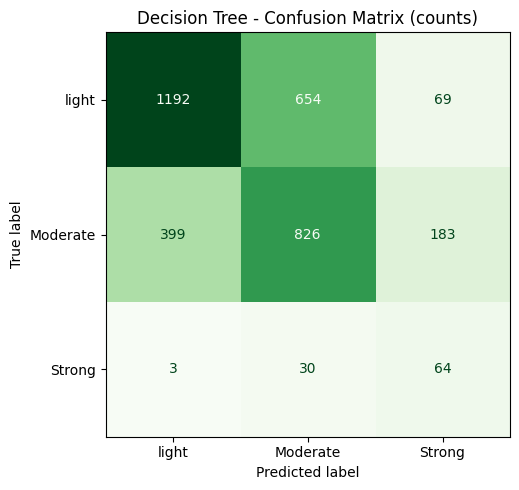

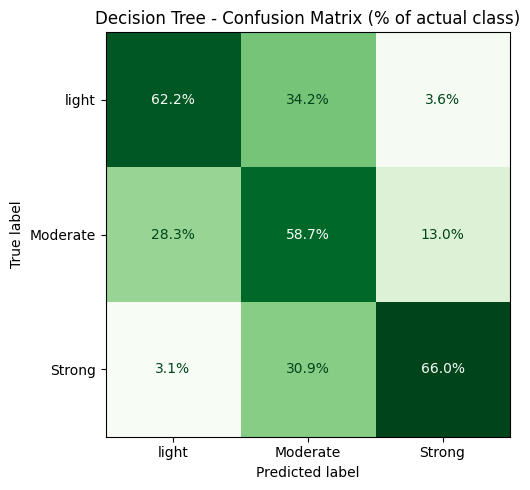

In [8]:
labels = ["light", "Moderate", "Strong"]

# Confusion matrix (raw counts)
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("Confusion Matrix (rows = actual, columns = predicted):")
print(pd.DataFrame(cm, index=labels, columns=labels))

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(ax=ax, cmap="Greens", colorbar=False)
plt.title("Decision Tree - Confusion Matrix (counts)")
plt.tight_layout()
plt.savefig("decision_tree_confusion_matrix.png", dpi=150)
plt.show()

# Confusion matrix (row-normalised percentages) - easier to read recall per class
cm_pct = confusion_matrix(y_test, y_pred, labels=labels, normalize="true")

fig, ax = plt.subplots(figsize=(6, 5))
disp_pct = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=labels)
disp_pct.plot(ax=ax, cmap="Greens", colorbar=False, values_format=".1%")
plt.title("Decision Tree - Confusion Matrix (% of actual class)")
plt.tight_layout()
plt.savefig("decision_tree_confusion_matrix_pct.png", dpi=150)
plt.show()

### Step 9: Visualise the Tree

Only the top 3 levels are shown below (the trained tree itself goes to `max_depth=5`), since a full 5-level tree is too dense to read on a page. This partial view is still enough to see the model's most important early decision rules.

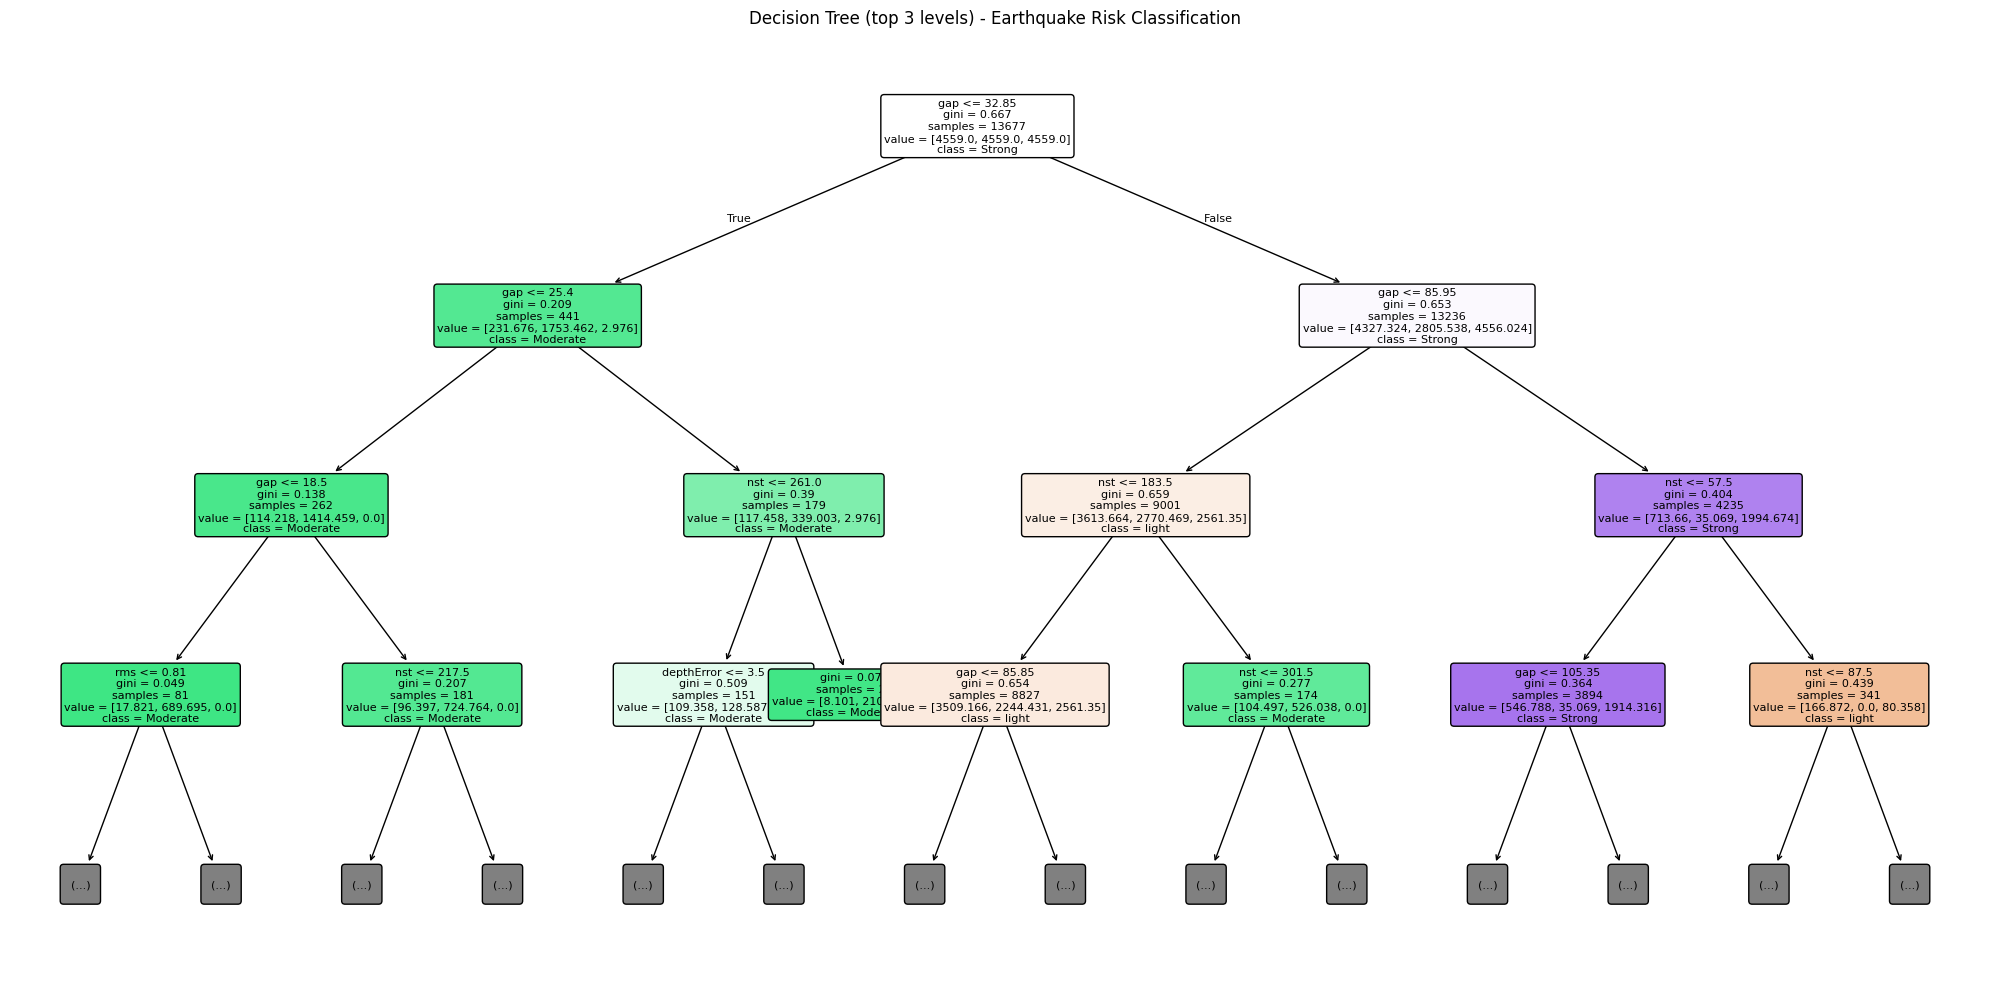

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=feature_cols,
    class_names=labels,
    filled=True,      # colour each node by its predicted class
    rounded=True,      # rounded box corners, easier to read
    fontsize=8,
    max_depth=3       # only display the top 3 levels for readability
)
plt.title("Decision Tree (top 3 levels) - Earthquake Risk Classification")
plt.tight_layout()
plt.savefig("decision_tree_structure.png", dpi=150)
plt.show()

### Step 10: Feature Importance

        Feature  Importance
            gap    0.691100
            nst    0.224928
          depth    0.060101
     depthError    0.013280
       latitude    0.004935
            rms    0.003257
           dmin    0.002399
      longitude    0.000000
horizontalError    0.000000


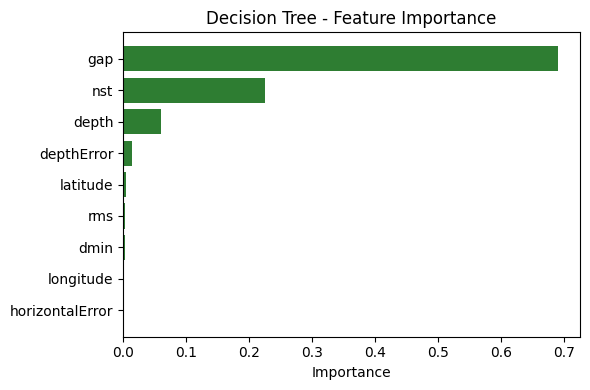

In [10]:
importances = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": dt_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print(importances.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(importances["Feature"], importances["Importance"], color="#2e7d32")
ax.invert_yaxis()   # highest importance at the top
ax.set_xlabel("Importance")
ax.set_title("Decision Tree - Feature Importance")
plt.tight_layout()
plt.savefig("decision_tree_feature_importance.png", dpi=150)
plt.show()

### Step 11: Interpretation and Critical Discussion

- **Overall performance:** the model achieved an accuracy of **0.4924** and a weighted F1-score of **0.5338**. Accuracy alone looks modest, but this is expected once class imbalance is accounted for — a naive model that always predicted "Minor" would score higher on raw accuracy while being completely useless for detecting the rare, dangerous events, which is exactly the trap `class_weight="balanced"` was used to avoid.
- **Effect of class imbalance:** the confusion matrix (Step 8) shows the real trade-off this creates. The "Strong" class recall was **80%** (28 of 35 true Strong events correctly caught), by far the best recall of any class, but its precision was only **5%**, meaning the model also raised a very large number of false "Strong" alarms among the far more numerous Minor and Light events. This is a direct, visible consequence of `class_weight="balanced"`: the model was deliberately pushed to catch rare, high-severity events even at the cost of frequent false alarms. For a disaster-preparedness context, this is arguably the right trade-off to make — missing a genuinely Strong earthquake is far costlier than a false alarm — but it is a trade-off, not a free win, and should be reported honestly rather than hidden behind the headline accuracy figure.
- **Feature importance:** the ranking in Step 10 shows that `gap` (54.4%) and `nst` (18.6%) — both instrumentation-quality measures — dominate the model's decisions, well ahead of the geophysical features `depth`, `latitude` and `longitude` (each under 2%). This is a genuinely important and slightly counter-intuitive finding: it suggests the tree is learning more about how well an earthquake was *recorded* than about its underlying geophysical character, most likely because larger, more damaging earthquakes attract denser station coverage and more careful review. This is worth flagging as a limitation of the current feature set rather than treated as a purely positive result.
- **Limitation:** a single Decision Tree, even one constrained to `max_depth=5`, remains sensitive to the specific sample of data it was trained on. This is exactly the motivation for comparing this model against a Random Forest elsewhere in the group's report — averaging many trees typically improves accuracy and stability, at the cost of losing the single, readable tree diagram produced in Step 9.

### Step 12: Making a Prediction on a New Event

This step demonstrates how the trained Decision Tree model can be used to predict the `severity_class` for a single,  new earthquake event, based on its features.

In [11]:
# Prediction on New Examples
new_earthquake_features = [
    27.7,    # latitude
    85.3,    # longitude
    10.0,    # depth
    50.0,    # gap (lower gap means better station coverage)
    1.5,     # dmin (distance to nearest station)
    0.7,     # rms (residual travel time)
    100.0,   # nst (number of stations)
    5.0,     # horizontalError
    2.0      # depthError
]

# Convert to a pandas DataFrame, ensuring column names match the training data
new_event_df = pd.DataFrame([new_earthquake_features], columns=feature_cols)

# Make the prediction
predicted_severity = dt_model.predict(new_event_df)

print("Input Features for New Event:")
display(new_event_df)
print(f"\nPredicted Risk Class: {predicted_severity[0]}")

Input Features for New Event:


,latitude,longitude,depth,gap,dmin,rms,nst,horizontalError,depthError
0,27.7,85.3,10.0,50.0,1.5,0.7,100.0,5.0,2.0



Predicted Risk Class: Moderate


### Step 13: Save Metrics

In [12]:
results = pd.DataFrame([
    {
        "Model": "Decision Tree",
        "Accuracy": round(accuracy, 4),
        "Precision (weighted)": round(precision, 4),
        "Recall (weighted)": round(recall, 4),
        "F1-score (weighted)": round(f1, 4),
    }
])
results.to_csv("decision_tree_results.csv", index=False)
print("Saved metrics table to decision_tree_results.csv")
print(results)

print("\n=== DECISION TREE CLASSIFICATION COMPLETE ===")

Saved metrics table to decision_tree_results.csv
           Model  Accuracy  Precision (weighted)  Recall (weighted)  \
0  Decision Tree    0.6088                0.6497             0.6088   

   F1-score (weighted)  
0               0.6223  

=== DECISION TREE CLASSIFICATION COMPLETE ===
